In [1]:
# Importing the required packages
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree, DecisionTreeClassifier
import matplotlib.pyplot as plt

In [5]:
# Function to import the dataset
def importdata():
    balance_data = pd.read_csv(
    'https://archive.ics.uci.edu/ml/machine-learning-' + 'databases/balance-scale/balance-scale.data', sep=',', header=None)
    # Displaying dataset information
    print("Dataset Length: ", len(balance_data))
    print("Dataset Shape: ", balance_data.shape)
    print("Dataset: ", balance_data.head())

    return balance_data

In [6]:
# Function to split the dataset into features and target variables
def splitdataset(balance_data):
    # Separating the target variable
    X = balance_data.values[:, 1:5]
    Y = balance_data.values[:, 0]
    # Splitting the dataset into train and test
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=100)
    
    return X, Y, X_train, X_test, y_train, y_test

In [7]:
def train_using_gini(X_train, X_test, y_train):
    # Creating the classifier object
    clf_gini = DecisionTreeClassifier(criterion="gini", random_state=100, max_depth=3, min_samples_leaf=5)
    # Performing training
    clf_gini.fit(X_train, y_train)
 
    return clf_gini

In [9]:
def train_using_entropy(X_train, X_test, y_train):
    # Decision tree with entropy
    clf_entropy = DecisionTreeClassifier(criterion="entropy", random_state=100, max_depth=3, min_samples_leaf=5)
    # Performing training
    clf_entropy.fit(X_train, y_train)
    
    return clf_entropy

In [10]:
# Function to make predictions
def prediction(X_test, clf_object):
    y_pred = clf_object.predict(X_test)
    print("Predicted values:")
    print(y_pred)
    return y_pred

# Placeholder function for cal_accuracy
def cal_accuracy(y_test, y_pred):
    print("Confusion Matrix: ",
    confusion_matrix(y_test, y_pred))
    print("Accuracy : ",
    accuracy_score(y_test, y_pred)*100)
    print("Report : ",
    classification_report(y_test, y_pred))

Dataset Length:  625
Dataset Shape:  (625, 5)
Dataset:     0  1  2  3  4
0  B  1  1  1  1
1  R  1  1  1  2
2  R  1  1  1  3
3  R  1  1  1  4
4  R  1  1  1  5


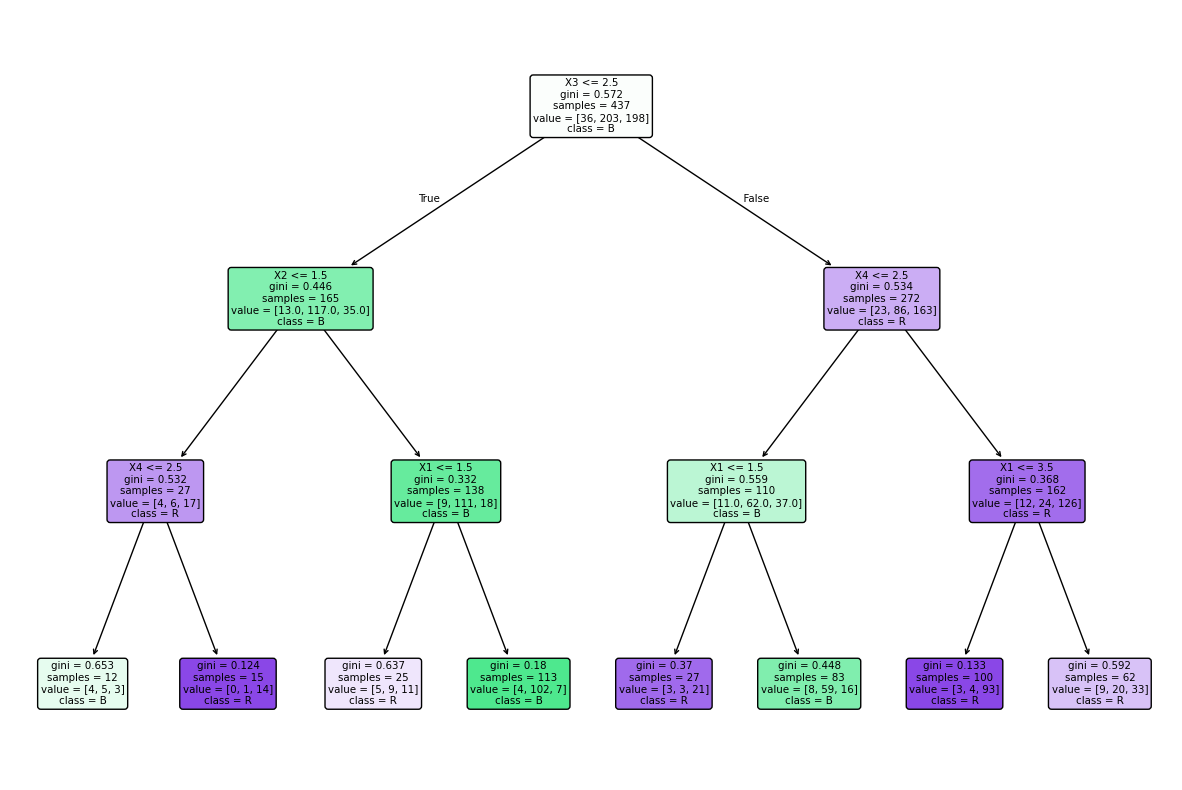

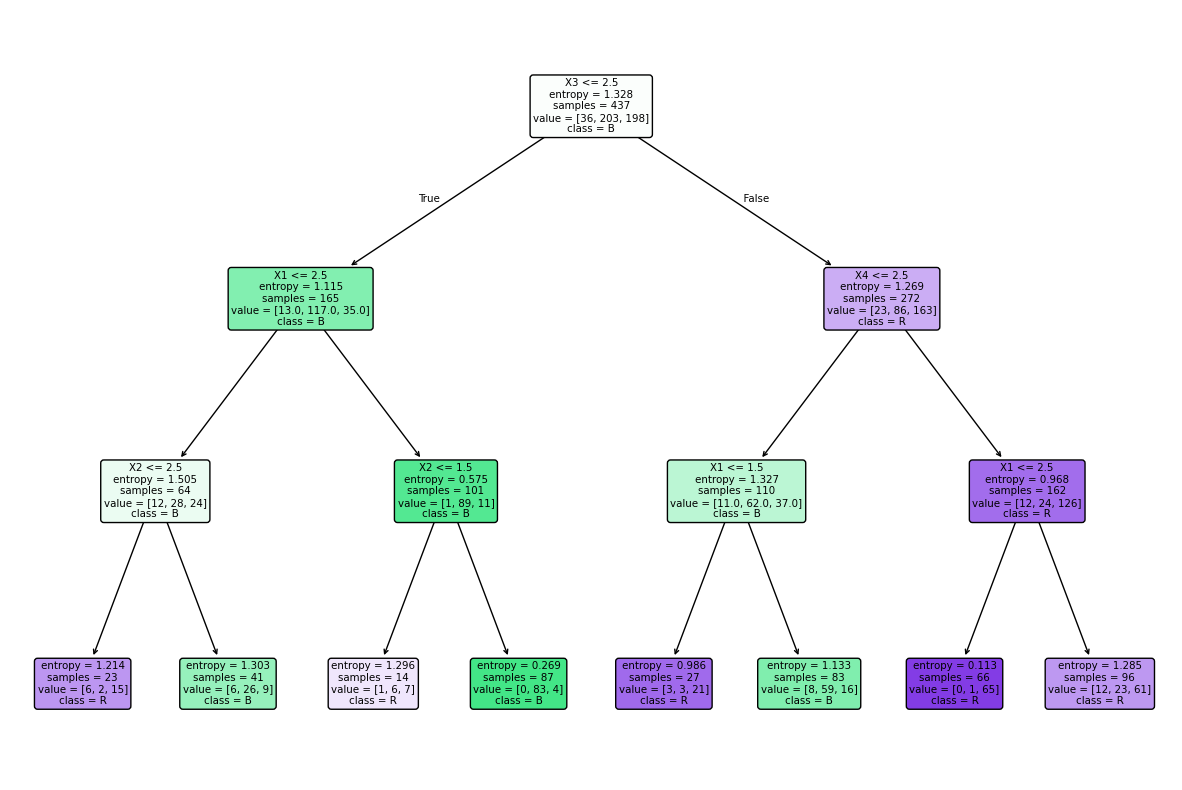

In [11]:
from sklearn import tree
# Function to plot the decision tree
def plot_decision_tree(clf_object, feature_names, class_names):
    plt.figure(figsize=(15, 10))
    plot_tree(clf_object, filled=True, feature_names=feature_names, class_names=class_names, rounded=True)
    plt.show()

if __name__ == "__main__":
    data = importdata()
    X, Y, X_train, X_test, y_train, y_test = splitdataset(data)
    clf_gini = train_using_gini(X_train, X_test, y_train)
    clf_entropy = train_using_entropy(X_train, X_test, y_train)
    # Visualizing the Decision Trees
    plot_decision_tree(clf_gini, ['X1', 'X2', 'X3', 'X4'], ['L', 'B', 'R'])
    plot_decision_tree(clf_entropy, ['X1', 'X2', 'X3', 'X4'], ['L', 'B', 'R'])

In [12]:
# Operational Phase
print("Results Using Gini Index:")
y_pred_gini = prediction(X_test, clf_gini)
cal_accuracy(y_test, y_pred_gini)

Results Using Gini Index:
Predicted values:
['R' 'L' 'R' 'R' 'R' 'L' 'R' 'L' 'L' 'L' 'R' 'L' 'L' 'L' 'R' 'L' 'R' 'L'
 'L' 'R' 'L' 'R' 'L' 'L' 'R' 'L' 'L' 'L' 'R' 'L' 'L' 'L' 'R' 'L' 'L' 'L'
 'L' 'R' 'L' 'L' 'R' 'L' 'R' 'L' 'R' 'R' 'L' 'L' 'R' 'L' 'R' 'R' 'L' 'R'
 'R' 'L' 'R' 'R' 'L' 'L' 'R' 'R' 'L' 'L' 'L' 'L' 'L' 'R' 'R' 'L' 'L' 'R'
 'R' 'L' 'R' 'L' 'R' 'R' 'R' 'L' 'R' 'L' 'L' 'L' 'L' 'R' 'R' 'L' 'R' 'L'
 'R' 'R' 'L' 'L' 'L' 'R' 'R' 'L' 'L' 'L' 'R' 'L' 'R' 'R' 'R' 'R' 'R' 'R'
 'R' 'L' 'R' 'L' 'R' 'R' 'L' 'R' 'R' 'R' 'R' 'R' 'L' 'R' 'L' 'L' 'L' 'L'
 'L' 'L' 'L' 'R' 'R' 'R' 'R' 'L' 'R' 'R' 'R' 'L' 'L' 'R' 'L' 'R' 'L' 'R'
 'L' 'L' 'R' 'L' 'L' 'R' 'L' 'R' 'L' 'R' 'R' 'R' 'L' 'R' 'R' 'R' 'R' 'R'
 'L' 'L' 'R' 'R' 'R' 'R' 'L' 'R' 'R' 'R' 'L' 'R' 'L' 'L' 'L' 'L' 'R' 'R'
 'L' 'R' 'R' 'L' 'L' 'R' 'R' 'R']
Confusion Matrix:  [[ 0  6  7]
 [ 0 67 18]
 [ 0 19 71]]
Accuracy :  73.40425531914893
Report :                precision    recall  f1-score   support

           B       0.00      0.00      0.

C:\Program Files\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Program Files\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Program Files\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [13]:
# Operational Phase
print("Results Using Entropy:")
y_pred_entropy = prediction(X_test, clf_entropy)
cal_accuracy(y_test, y_pred_entropy)

Results Using Entropy:
Predicted values:
['R' 'L' 'R' 'L' 'R' 'L' 'R' 'L' 'R' 'R' 'R' 'R' 'L' 'L' 'R' 'L' 'R' 'L'
 'L' 'R' 'L' 'R' 'L' 'L' 'R' 'L' 'R' 'L' 'R' 'L' 'R' 'L' 'R' 'L' 'L' 'L'
 'L' 'L' 'R' 'L' 'R' 'L' 'R' 'L' 'R' 'R' 'L' 'L' 'R' 'L' 'L' 'R' 'L' 'L'
 'R' 'L' 'R' 'R' 'L' 'R' 'R' 'R' 'L' 'L' 'R' 'L' 'L' 'R' 'L' 'L' 'L' 'R'
 'R' 'L' 'R' 'L' 'R' 'R' 'R' 'L' 'R' 'L' 'L' 'L' 'L' 'R' 'R' 'L' 'R' 'L'
 'R' 'R' 'L' 'L' 'L' 'R' 'R' 'L' 'L' 'L' 'R' 'L' 'L' 'R' 'R' 'R' 'R' 'R'
 'R' 'L' 'R' 'L' 'R' 'R' 'L' 'R' 'R' 'L' 'R' 'R' 'L' 'R' 'R' 'R' 'L' 'L'
 'L' 'L' 'L' 'R' 'R' 'R' 'R' 'L' 'R' 'R' 'R' 'L' 'L' 'R' 'L' 'R' 'L' 'R'
 'L' 'R' 'R' 'L' 'L' 'R' 'L' 'R' 'R' 'R' 'R' 'R' 'L' 'R' 'R' 'R' 'R' 'R'
 'R' 'L' 'R' 'L' 'R' 'R' 'L' 'R' 'L' 'R' 'L' 'R' 'L' 'L' 'L' 'L' 'L' 'R'
 'R' 'R' 'L' 'L' 'L' 'R' 'R' 'R']
Confusion Matrix:  [[ 0  6  7]
 [ 0 63 22]
 [ 0 20 70]]
Accuracy :  70.74468085106383
Report :                precision    recall  f1-score   support

           B       0.00      0.00      0.00 

C:\Program Files\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Program Files\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Program Files\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [14]:
# importing required libraries
# importing Scikit-learn library and datasets package
from sklearn import datasets
# Loading the iris plants dataset (classification)
iris = datasets.load_iris()

In [15]:
print(iris.target_names)
print(iris.feature_names)

['setosa' 'versicolor' 'virginica']
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [16]:
# dividing the datasets into two parts i.e. training datasets and test datasets
X, y = datasets.load_iris( return_X_y = True)
# Splitting arrays or matrices into random train and test subsets
from sklearn.model_selection import train_test_split
# i.e. 70 % training dataset and 30 % test datasets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30)

In [17]:
# importing random forest classifier from assemble module
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
# creating dataframe of IRIS dataset
data = pd.DataFrame({'sepallength': iris.data[:, 0], 'sepalwidth': iris.data[:, 1], 'petallength': iris.data[:, 2], 'petalwidth': iris.data[:, 3], 'species': iris.target})
# printing the top 5 datasets in iris dataset
print(data.head())

   sepallength  sepalwidth  petallength  petalwidth  species
0          5.1         3.5          1.4         0.2        0
1          4.9         3.0          1.4         0.2        0
2          4.7         3.2          1.3         0.2        0
3          4.6         3.1          1.5         0.2        0
4          5.0         3.6          1.4         0.2        0


In [18]:
# creating a RF classifier
clf = RandomForestClassifier(n_estimators = 100)

# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf.fit(X_train, y_train)

# performing predictions on the test dataset
y_pred = clf.predict(X_test)

# metrics are used to find accuracy or error
from sklearn import metrics
print()

# using metrics module for accuracy calculation
print("ACCURACY OF THE MODEL:", metrics.accuracy_score(y_test, y_pred))


ACCURACY OF THE MODEL: 0.9333333333333333


In [19]:
# predicting which type of flower it is.
clf.predict([[3, 3, 2, 2]])

array([2])

In [20]:
# using the feature importance variable
import pandas as pd
feature_imp = pd.Series(clf.feature_importances_, index = iris.feature_names).sort_values(
ascending = False)
feature_imp

petal width (cm)     0.448906
petal length (cm)    0.424437
sepal length (cm)    0.083333
sepal width (cm)     0.043324
dtype: float64

In [21]:
# Load the important packages
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.svm import SVC

In [22]:
# Load the datasets
cancer = load_breast_cancer()
X = cancer.data[:, :2]
y = cancer.target

In [23]:
#Build the model
svm = SVC(kernel="rbf", gamma=0.5, C=1.0)
# Trained the model
svm.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.5
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


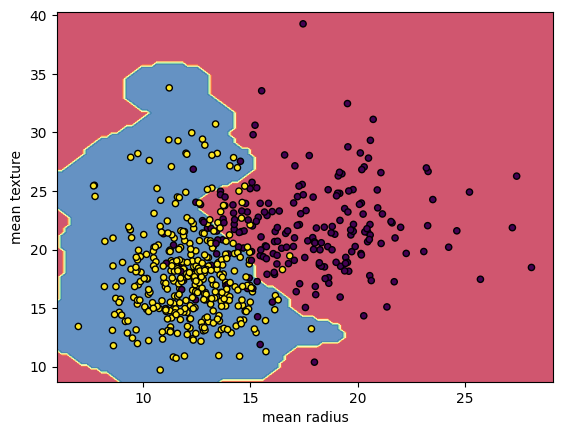

In [25]:
# Plot Decision Boundary
DecisionBoundaryDisplay.from_estimator(svm, X, response_method="predict", cmap=plt.cm.Spectral, alpha=0.8, xlabel=cancer.feature_names[0], ylabel=cancer.feature_names[1],)
# Scatter plot
plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolors="k")
plt.show()

In [1]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
data = {
 'feature1': [0.1, 0.2, 0.3, 0.4, 0.5],
 'feature2': [0.5, 0.4, 0.3, 0.2, 0.1],
 'label': [0, 0, 1, 1, 1]
}
df = pd.DataFrame(data)
X = df[['feature1', 'feature2']].values
y = df['label'].values

In [3]:
model = Sequential()
model.add(Dense(8, input_dim=2, activation='relu')) # Hidden layer
model.add(Dense(1, activation='sigmoid')) # Output layer

C:\Program Files\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [5]:
model.fit(X, y, epochs=100, batch_size=1, verbose=1)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6000 - loss: 0.6918   
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6000 - loss: 0.6881    
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6000 - loss: 0.6858     
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6000 - loss: 0.6829  
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6000 - loss: 0.6801     
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6000 - loss: 0.6774  
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6000 - loss: 0.6748      
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6000 - loss: 0.6723     
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6000 - loss: 0.6696 
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6000 - loss: 0.6673 
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6000 - loss: 0.6644     
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s

In [6]:
test_data = np.array([[0.2, 0.4]])
prediction = model.predict(test_data)
predicted_label = (prediction > 0.5).astype(int)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


In [7]:
# import the necessary libraries
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from itertools import product

In [8]:
# set the param
plt.rc('figure', autolayout=True)
plt.rc('image', cmap='magma')
# define the kernel
kernel = tf.constant([[-1, -1, -1],
 [-1, 8, -1],
 [-1, -1, -1],
 ])

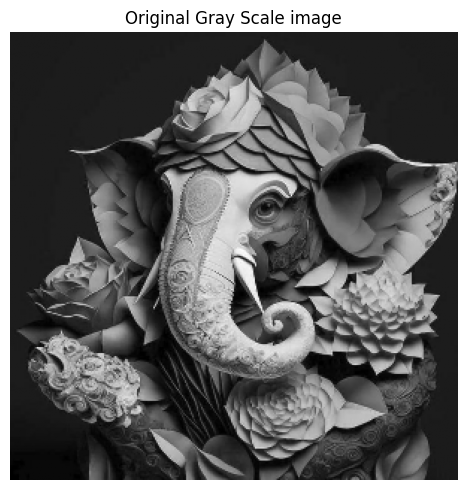

In [10]:
# load the image
image = tf.io.read_file(r'C:\Facultate\Facultate\Anul 3\Semestrul 1\KBS\Lab\Lab 7\Ganesh.jpg')
image = tf.io.decode_jpeg(image, channels=1)
image = tf.image.resize(image, size=[300, 300])

# plot the image
img = tf.squeeze(image).numpy()
plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title('Original Gray Scale image')
plt.show();

In [11]:
# Reformat
image = tf.image.convert_image_dtype(image, dtype=tf.float32)
image = tf.expand_dims(image, axis=0)
kernel = tf.reshape(kernel, [*kernel.shape, 1, 1])
kernel = tf.cast(kernel, dtype=tf.float32)

In [13]:
# convolution layer
conv_fn = tf.nn.conv2d
image_filter = conv_fn(
    input=image,
    filters=kernel,
    strides=1, # or (1, 1)
    padding='SAME',
)

Text(0.5, 1.0, 'Convolution')

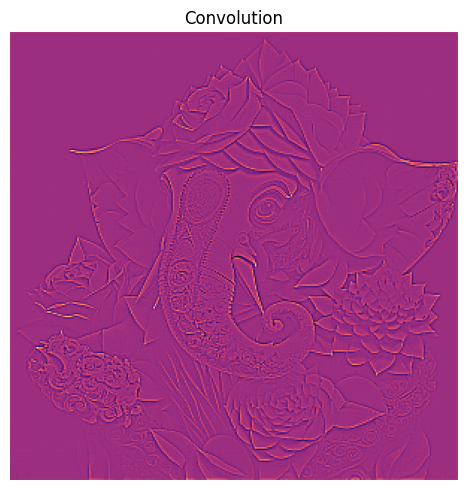

In [14]:
plt.figure(figsize=(15, 5))
# Plot the convolved image
plt.subplot(1, 3, 1)
plt.imshow(tf.squeeze(image_filter))
plt.axis('off')
plt.title('Convolution')

In [15]:
# activation layer
relu_fn = tf.nn.relu
# Image detection
image_detect = relu_fn(image_filter)

Text(0.5, 1.0, 'Activation')

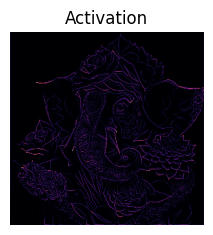

In [16]:
plt.subplot(1, 3, 2)
plt.imshow(
 # Reformat for plotting
 tf.squeeze(image_detect)
)
plt.axis('off')
plt.title('Activation')

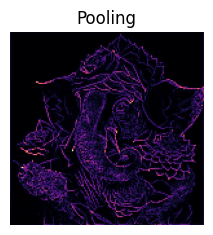

In [17]:
# Pooling layer
pool = tf.nn.pool
image_condense = pool(input=image_detect,
    window_shape=(2, 2),
    pooling_type='MAX',
    strides=(2, 2),
    padding='SAME',
    )

plt.subplot(1, 3, 3)
plt.imshow(tf.squeeze(image_condense))
plt.axis('off')
plt.title('Pooling')
plt.show()

In [18]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [19]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
print("Train images:", X_train.shape)
print("Train labels:", y_train.shape)
print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train images: (60000, 28, 28)
Train labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


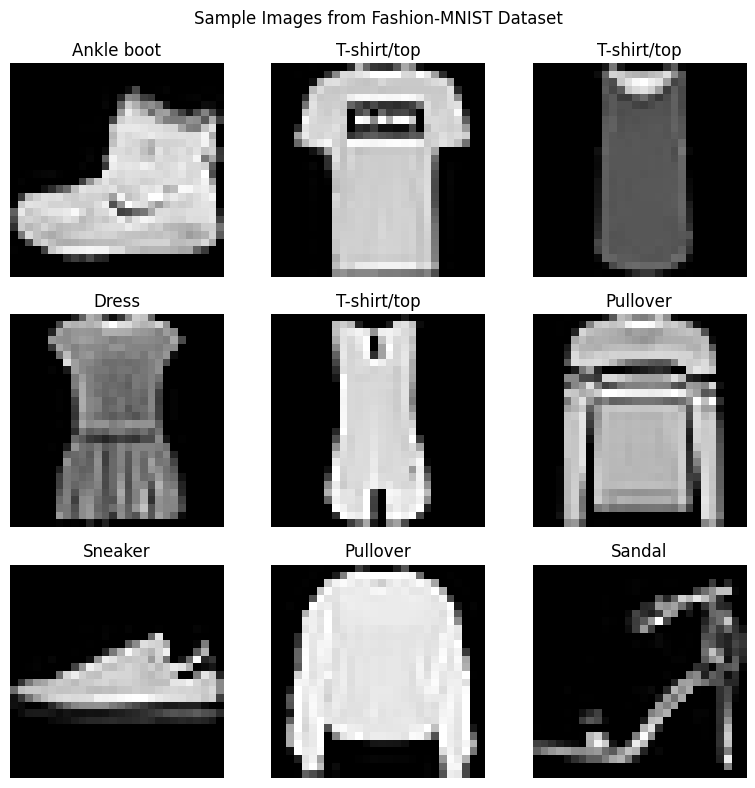

In [20]:
# Visualize sample images
import matplotlib.pyplot as plt

# Class labels for Fashion-MNIST
class_names = [
 "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
 "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Plot a grid of sample images
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
    
plt.suptitle("Sample Images from Fashion-MNIST Dataset")
plt.show()

In [21]:
# Check Class Distribution and Inspect Pixel Value Range
import numpy as np

unique, counts = np.unique(y_train, return_counts=True)

for label, count in zip(unique, counts):
    print(f"Class {label} ({class_names[label]}): {count} samples")
    
print("Minimum pixel value:", X_train.min())
print("Maximum pixel value:", X_train.max())

Class 0 (T-shirt/top): 6000 samples
Class 1 (Trouser): 6000 samples
Class 2 (Pullover): 6000 samples
Class 3 (Dress): 6000 samples
Class 4 (Coat): 6000 samples
Class 5 (Sandal): 6000 samples
Class 6 (Shirt): 6000 samples
Class 7 (Sneaker): 6000 samples
Class 8 (Bag): 6000 samples
Class 9 (Ankle boot): 6000 samples
Minimum pixel value: 0
Maximum pixel value: 255


In [22]:
# Normalize pixel values from [0, 255] to [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Add channel dimension: (samples, height, width, channels)
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print("Train images after reshape:", X_train.shape)
print("Test images after reshape:", X_test.shape)

Train images after reshape: (60000, 28, 28, 1)
Test images after reshape: (10000, 28, 28, 1)


In [23]:
model = Sequential()

# Block 1: feature extraction
model.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2: deeper feature extraction
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Classification head
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3)) # reduces overfitting
model.add(Dense(10, activation='softmax')) # 10 classes

C:\Program Files\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.compile(
 optimizer='adam',
 loss='sparse_categorical_crossentropy',
 metrics=['accuracy']
)

In [25]:
history = model.fit(
 X_train, y_train,
 epochs=5,
 batch_size=64,
 validation_split=0.1,
 verbose=1
)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.7720 - loss: 0.6296 - val_accuracy: 0.8463 - val_loss: 0.4190
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - accuracy: 0.8471 - loss: 0.4228 - val_accuracy: 0.8663 - val_loss: 0.3564
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 16ms/step - accuracy: 0.8656 - loss: 0.3693 - val_accuracy: 0.8817 - val_loss: 0.3216
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - accuracy: 0.8765 - loss: 0.3393 - val_accuracy: 0.8822 - val_loss: 0.3141
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 19s 17ms/step - accuracy: 0.8838 - loss: 0.3191 - val_accuracy: 0.8868 - val_loss: 0.2992


In [26]:
# Evaluate on the test set:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test accuracy:", test_acc)

# Make a prediction for one image:
sample = X_test[0:1] # one image (shape: 1, 28, 28, 1)
proba = model.predict(sample)
predicted_class = np.argmax(proba)

print("Predicted class:", predicted_class)
print("True class:", y_test[0])

# Class Name Mapping (for readability)
class_names = [
 "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
 "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("Predicted:", class_names[predicted_class])
print("True:", class_names[y_test[0]])

Test accuracy: 0.8855000138282776
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
Predicted class: 9
True class: 9
Predicted: Ankle boot
True: Ankle boot


In [27]:
from tensorflow.keras.layers import BatchNormalization

model = Sequential()

# Block 1: feature extraction
model.add(Conv2D(filters=16, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2: deeper feature extraction
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))

# Classification head
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3)) # reduces overfitting
model.add(Dense(10, activation='softmax')) # 10 classes

In [29]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
 monitor="val_accuracy",
 patience=3,
 restore_best_weights=True
)

model.compile(
 optimizer='adam',
 loss='sparse_categorical_crossentropy',
 metrics=['accuracy']
)

history = model.fit(
 X_train, y_train,
 epochs=30,
 batch_size=64,
 validation_split=0.1,
 callbacks=[early_stop],
 verbose=1
)

Epoch 1/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - accuracy: 0.8174 - loss: 0.5145 - val_accuracy: 0.8703 - val_loss: 0.3453
Epoch 2/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 26ms/step - accuracy: 0.8722 - loss: 0.3480 - val_accuracy: 0.8893 - val_loss: 0.3048
Epoch 3/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.8885 - loss: 0.3089 - val_accuracy: 0.8835 - val_loss: 0.3131
Epoch 4/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 31ms/step - accuracy: 0.8975 - loss: 0.2804 - val_accuracy: 0.8963 - val_loss: 0.2763
Epoch 5/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 37s 26ms/step - accuracy: 0.9024 - loss: 0.2630 - val_accuracy: 0.9015 - val_loss: 0.2743
Epoch 6/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.9079 - loss: 0.2466 - val_accuracy: 0.8930 - val_loss: 0.2949
Epoch 7/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 30ms/step - accuracy: 0.9129 - loss: 0.2318 - val_accuracy: 0.9077 - val_loss: 0.2587
Epoch 8/30
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.9166 - loss: 0.2243 - 

In [30]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [31]:
X = np.array([
 [[20], [21], [20], [22]], # normal
 [[30], [31], [29], [32]], # anomaly
 [[19], [20], [21], [20]], # normal
 [[28], [30], [31], [29]], # anomaly
 [[20], [20], [21], [21]], # normal
 [[33], [32], [34], [35]] # anomaly
])
y = np.array([0, 1, 0, 1, 0, 1])
print("X shape:", X.shape) # (samples, time_steps, features)
print("y shape:", y.shape)


X shape: (6, 4, 1)
y shape: (6,)


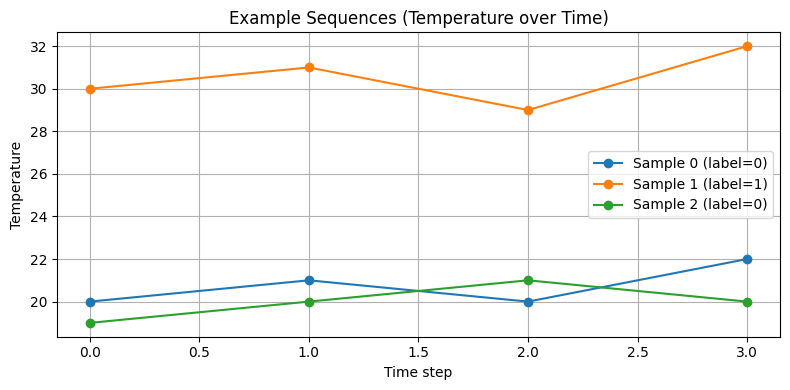

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
for i in range(3):
    seq = X[i].squeeze() # shape (4,)
    plt.plot(seq, marker='o', label=f"Sample {i} (label={y[i]})")
    
plt.title("Example Sequences (Temperature over Time)")
plt.xlabel("Time step")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
# Compute mean and std over the entire dataset
mean = X.mean()
std = X.std()
X_norm = (X - mean) / std

In [34]:
# Simple split: first 4 for training, last 2 for validation
X_train, X_val = X_norm[:4], X_norm[4:]
y_train, y_val = y[:4], y[4:]

In [35]:
model = Sequential()
model.add(SimpleRNN(8, input_shape=(4, 1), activation='tanh'))
model.add(Dense(1, activation='sigmoid'))

C:\Program Files\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
model.compile(
 loss='binary_crossentropy',
 optimizer='adam',
 metrics=['accuracy']
)

In [37]:
early_stop = EarlyStopping(
 monitor="val_accuracy",
 patience=5,
 restore_best_weights=True
)
lr_sched = ReduceLROnPlateau(
 monitor="val_loss",
 factor=0.5,
 patience=3,
 min_lr=1e-5,
 verbose=1
)
history = model.fit(
 X_train, y_train,
 epochs=100,
 validation_data=(X_val, y_val),
 callbacks=[early_stop, lr_sched],
 verbose=1
)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 1.0000 - loss: 0.3460 - val_accuracy: 1.0000 - val_loss: 0.3740 - learning_rate: 0.0010
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 1.0000 - loss: 0.3423 - val_accuracy: 1.0000 - val_loss: 0.3702 - learning_rate: 0.0010
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step - accuracy: 1.0000 - loss: 0.3387 - val_accuracy: 1.0000 - val_loss: 0.3664 - learning_rate: 0.0010
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 355ms/step - accuracy: 1.0000 - loss: 0.3350 - val_accuracy: 1.0000 - val_loss: 0.3627 - learning_rate: 0.0010
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 1.0000 - loss: 0.3315 - val_accuracy: 1.0000 - val_loss: 0.3590 - learning_rate: 0.0010
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step - accuracy: 1.0000 - loss: 0.3279 - val_accuracy: 1.0000 - val_loss: 0.3553 - learning_rate: 0.0010


In [38]:
test_sequence = np.array([[[21], [22], [21], [23]]])
test_sequence_norm = (test_sequence - mean) / std

prediction = model.predict(test_sequence_norm)
predicted_label = (prediction > 0.5).astype(int)

print("Prediction probability:", prediction[0][0])
print("Predicted label:", predicted_label[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step
Prediction probability: 0.24526168
Predicted label: 0
